# RWTH home-storage field measurements

This notebook lists the 21 released systems, loads one month of one system at 1 s resolution, and plots battery voltage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('rwth-home')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('rwth-home')
display(released)

,unit,archive,bytes,months,first_month,last_month
0,01,Data_ID_01.zip,973143312,80,2015-07,2022-12
1,02,Data_ID_02.zip,1103425538,76,2015-12,2022-12
2,03,Data_ID_03.zip,1153981898,71,2016-05,2022-12
3,04,Data_ID_04.zip,907687347,69,2016-06,2022-12
4,05,Data_ID_05.zip,855955141,57,2016-08,2022-09
5,06,Data_ID_06.zip,999553292,66,2016-09,2022-12
6,07,Data_ID_07.zip,2147184792,76,2015-11,2022-12
7,08,Data_ID_08.zip,1024608389,72,2015-10,2022-12
8,09,Data_ID_09.zip,1596772723,70,2015-07,2022-12
9,10,Data_ID_10.zip,785190153,66,2016-10,2022-12


Each row is one home-storage system with its number of monthly files and first and last month.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('rwth-home', unit=1, month='2015-08')
print(frame.shape)
display(frame.head())

(1209600, 7)


,P_in_W,V_in_V,I_in_A,T_Bat_in_C,T_Room_in_C,Interpolated,unit
Time,,,,,,,
2015-08-01 00:00:00,-0.0,137.731,0.0,25.0563,21.6767,0,01
2015-08-01 00:00:01,-0.0,137.728,0.0,25.0560,21.6773,0,01
2015-08-01 00:00:02,-0.0,137.723,0.0,25.0553,21.6759,0,01
2015-08-01 00:00:03,-0.0,137.729,0.0,25.0555,21.6772,0,01
2015-08-01 00:00:04,-0.0,137.707,0.0,25.0563,21.6756,0,01


The August 2015 file of system 01 at 1 s resolution. The release carries battery power, voltage, current and temperature, room temperature, and a flag for values the publisher filled.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['P_in_W', 'V_in_V', 'I_in_A', 'T_Bat_in_C', 'T_Room_in_C']].describe().T)

,count,mean,std,min,25%,50%,75%,max
P_in_W,1209600.0,4.391317,413.317252,-2047.4700,-0.0000,-0.0000,0.0000,2069.6300
V_in_V,1209600.0,147.328137,11.330157,136.3850,137.8910,139.1830,163.0050,165.1590
I_in_A,1209600.0,0.016695,2.706537,-12.6283,0.0000,0.0000,0.0000,12.7390
T_Bat_in_C,1209600.0,26.043721,1.039471,23.3424,25.2997,26.0900,26.8533,28.5205
T_Room_in_C,1209600.0,23.427347,0.873007,21.3713,23.0830,23.4313,24.1261,24.9457


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

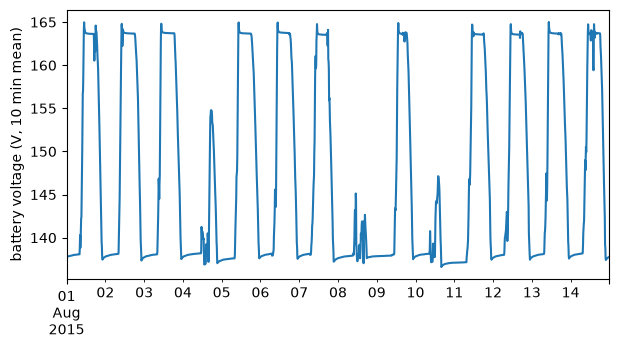

In [4]:
ax = frame['V_in_V'].resample('10min').mean().plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('battery voltage (V, 10 min mean)')
plt.show()

Battery voltage follows a daily cycle, rising while the system charges during the day and falling as it discharges in the evening and night.